# Credit Risk Intelligence System — Exploratory Data Analysis

## Objective

Analyze borrower behavior, loan characteristics, and default patterns using LendingClub loan data.

## Business Goals

- Identify key drivers of loan default
- Detect risky borrower segments
- Improve underwriting strategy
- Understand pricing vs. risk relationships

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load cleaned dataset
df = pd.read_parquet(
    '../data/processed/cleaned_loans.parquet'
)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (1303638, 29)


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,target,emp_length_missing,revol_util_missing,pub_rec_bankruptcies_missing,emp_length_years,credit_history_years,issue_year,issue_quarter
0,30000,30000,36,22.350000,1151.160034,D,D5,MORTGAGE,100000.0,Source Verified,debt_consolidation,30.459999,0.0,0.0,11.0,1.0,15603,37.000000,19.0,1.0,1.0,0,0,0,0,5.0,6.915811,2018,4
1,40000,40000,60,16.139999,975.710022,C,C4,MORTGAGE,45000.0,Verified,credit_card,50.529999,0.0,0.0,18.0,0.0,34971,64.500000,37.0,1.0,0.0,0,0,0,0,0.0,9.500342,2018,4
2,20000,20000,36,7.560000,622.679993,A,A3,MORTGAGE,100000.0,Not Verified,credit_card,18.920000,0.0,0.0,9.0,0.0,25416,29.900000,19.0,5.0,0.0,0,0,0,0,10.0,19.830253,2018,4
3,4500,4500,36,11.310000,147.990005,B,B3,RENT,38500.0,Not Verified,credit_card,4.640000,0.0,0.0,12.0,0.0,4472,15.300000,25.0,0.0,0.0,0,0,0,0,10.0,15.000684,2018,4
4,8425,8425,36,27.270000,345.179993,E,E5,MORTGAGE,450000.0,Verified,credit_card,12.370000,0.0,0.0,21.0,0.0,36812,65.699997,37.0,4.0,0.0,0,0,0,0,3.0,21.166324,2018,4


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303638 entries, 0 to 1303637
Data columns (total 29 columns):
 #   Column                        Non-Null Count    Dtype   
---  ------                        --------------    -----   
 0   loan_amnt                     1303638 non-null  int32   
 1   funded_amnt                   1303638 non-null  int32   
 2   term                          1303638 non-null  int8    
 3   int_rate                      1303638 non-null  float32 
 4   installment                   1303638 non-null  float32 
 5   grade                         1303638 non-null  category
 6   sub_grade                     1303638 non-null  category
 7   home_ownership                1303638 non-null  category
 8   annual_inc                    1303638 non-null  float32 
 9   verification_status           1303638 non-null  category
 10  purpose                       1303638 non-null  category
 11  dti                           1303638 non-null  float32 
 12  delinq_2yrs              

## Dataset Summary

The dataset contains cleaned LendingClub loan records including:

- borrower financial metrics
- loan characteristics
- repayment outcomes
- credit behavior indicators

The target variable:
- 0 = Fully Paid
- 1 = Default / Charged Off

Default Rate: 20.07%


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_64192\1895283386.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


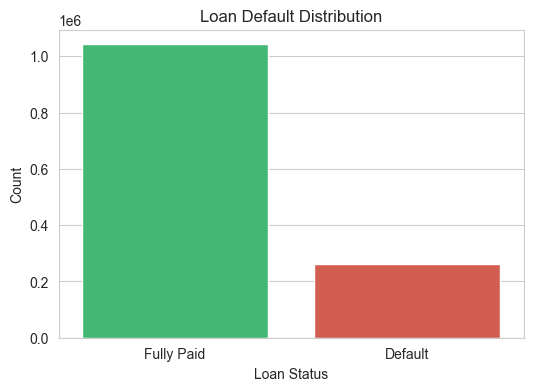

In [3]:
default_rate = df['target'].mean()

print(f"Default Rate: {default_rate:.2%}")

plt.figure(figsize=(6, 4))

sns.countplot(
    x='target',
    data=df,
    palette=['#2ecc71', '#e74c3c']
)

plt.xticks(
    [0, 1],
    ['Fully Paid', 'Default']
)

plt.title('Loan Default Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')

plt.show()

## Insight

Approximately 20% of loans defaulted.

This indicates moderate class imbalance and confirms the importance of accurate credit-risk modeling.

In [4]:
grade_analysis = df.groupby(
    'grade',
    observed=True
).agg(
    total_loans=('target', 'count'),
    defaults=('target', 'sum'),
    default_rate=('target', 'mean'),
    avg_int_rate=('int_rate', 'mean'),
    avg_loan_amnt=('loan_amnt', 'mean'),
    avg_annual_inc=('annual_inc', 'median')
).reset_index()

grade_analysis['default_rate_pct'] = (
    grade_analysis['default_rate'] * 100
)

grade_analysis

,grade,total_loans,defaults,default_rate,avg_int_rate,avg_loan_amnt,avg_annual_inc,default_rate_pct
0,A,226245,13768,0.060854,7.124554,13874.884749,75000.0,6.085438
1,B,380158,51083,0.134373,10.688108,13227.962584,65000.0,13.437308
2,C,369937,83271,0.225095,14.020658,14177.070015,61200.0,22.509508
3,D,195288,59449,0.304417,17.700357,15262.715451,60000.0,30.441707
4,E,91574,35368,0.386223,21.102659,17639.890963,61201.0,38.622316
5,F,31485,14265,0.453073,24.898905,19102.162935,65000.0,45.307289
6,G,8951,4482,0.500726,27.688070,20608.208580,65200.0,50.072618


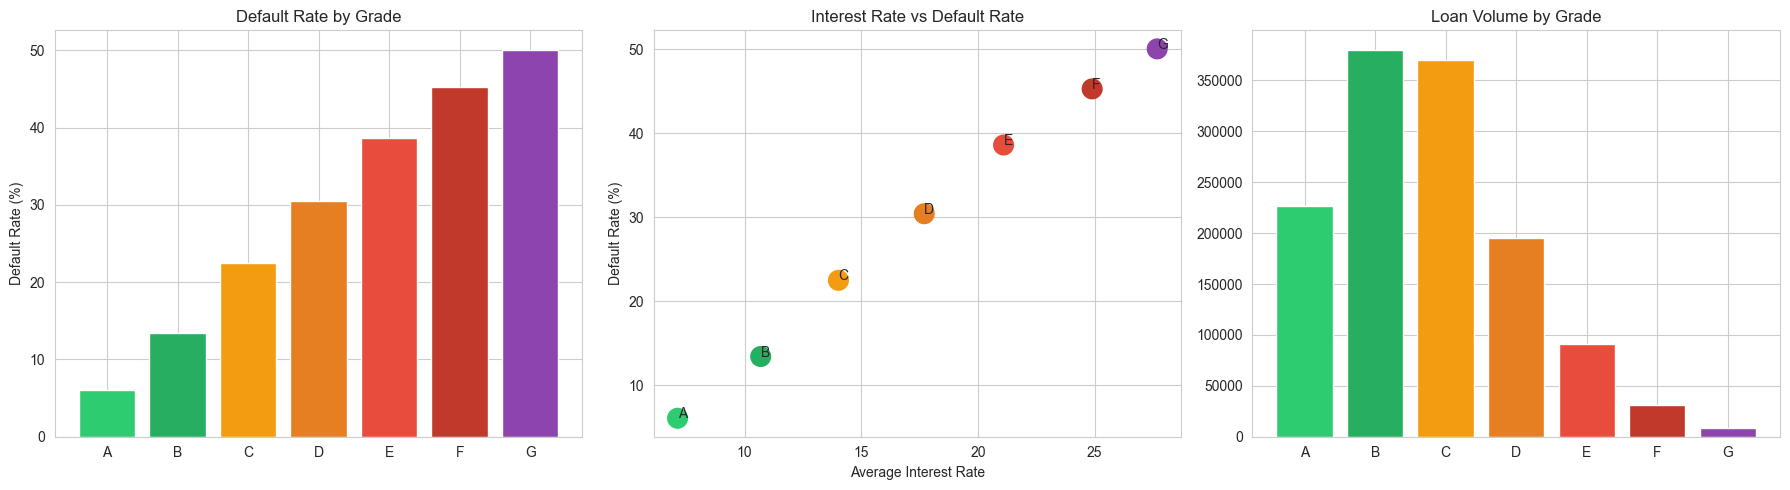

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = [
    '#2ecc71',
    '#27ae60',
    '#f39c12',
    '#e67e22',
    '#e74c3c',
    '#c0392b',
    '#8e44ad'
]

# Default rate by grade
axes[0].bar(
    grade_analysis['grade'],
    grade_analysis['default_rate_pct'],
    color=colors
)

axes[0].set_title('Default Rate by Grade')
axes[0].set_ylabel('Default Rate (%)')

# Interest rate vs default rate
axes[1].scatter(
    grade_analysis['avg_int_rate'],
    grade_analysis['default_rate_pct'],
    s=200,
    c=colors
)

for _, row in grade_analysis.iterrows():
    axes[1].annotate(
        row['grade'],
        (row['avg_int_rate'], row['default_rate_pct'])
    )

axes[1].set_title('Interest Rate vs Default Rate')
axes[1].set_xlabel('Average Interest Rate')
axes[1].set_ylabel('Default Rate (%)')

# Loan volume
axes[2].bar(
    grade_analysis['grade'],
    grade_analysis['total_loans'],
    color=colors
)

axes[2].set_title('Loan Volume by Grade')

plt.tight_layout()

plt.savefig(
    '../outputs/grade_risk_analysis.png',
    dpi=150
)

plt.show()

## Key Insight

Loan grade strongly predicts default behavior.

Higher-risk grades exhibit substantially higher default rates, showing that LendingClub’s grading system captures borrower risk reasonably well.

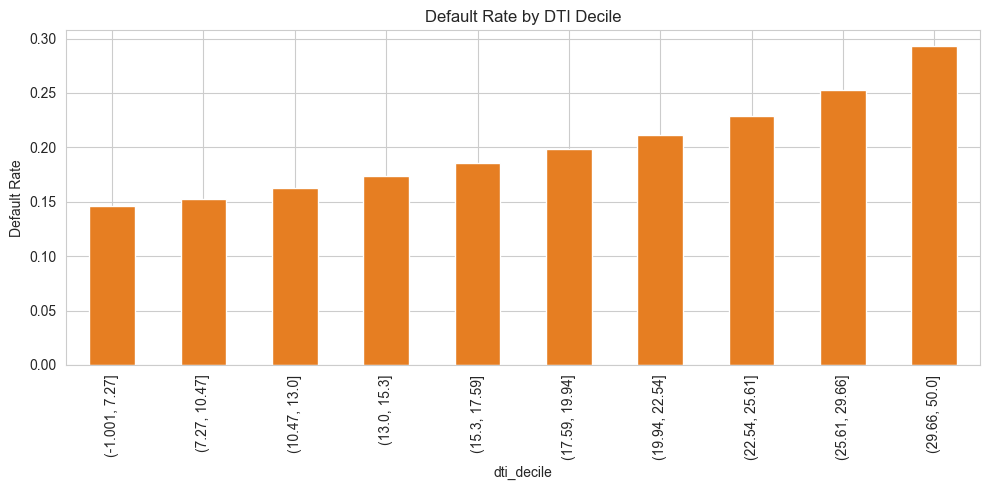

In [6]:
dti_data = df[df['dti'] <= 50].copy()

dti_data['dti_decile'] = pd.qcut(
    dti_data['dti'],
    q=10,
    duplicates='drop'
)

dti_analysis = dti_data.groupby(
    'dti_decile'
)['target'].mean()

plt.figure(figsize=(10, 5))

dti_analysis.plot(
    kind='bar',
    color='#e67e22'
)

plt.title('Default Rate by DTI Decile')
plt.ylabel('Default Rate')

plt.tight_layout()

plt.show()

## Key Insight

Default risk rises sharply as debt-to-income ratio increases.

Borrowers with excessive debt burdens are significantly more likely to default.

In [7]:
purpose_analysis = df.groupby(
    'purpose',
    observed=True
).agg(
    count=('target', 'count'),
    default_rate=('target', 'mean'),
    avg_loan_amnt=('loan_amnt', 'mean'),
    avg_int_rate=('int_rate', 'mean')
).reset_index()

purpose_analysis = purpose_analysis[
    purpose_analysis['count'] >= 500
]

purpose_analysis = purpose_analysis.sort_values(
    'default_rate'
)

purpose_analysis.head()

,purpose,count,default_rate,avg_loan_amnt,avg_int_rate
13,wedding,2294,0.121622,10535.156931,14.149808
0,car,14121,0.146449,8837.654911,12.084929
1,credit_card,285708,0.170279,14809.410745,11.802777
4,home_improvement,84497,0.178551,14152.426122,12.817100
6,major_purchase,28328,0.187235,11834.658289,12.743863


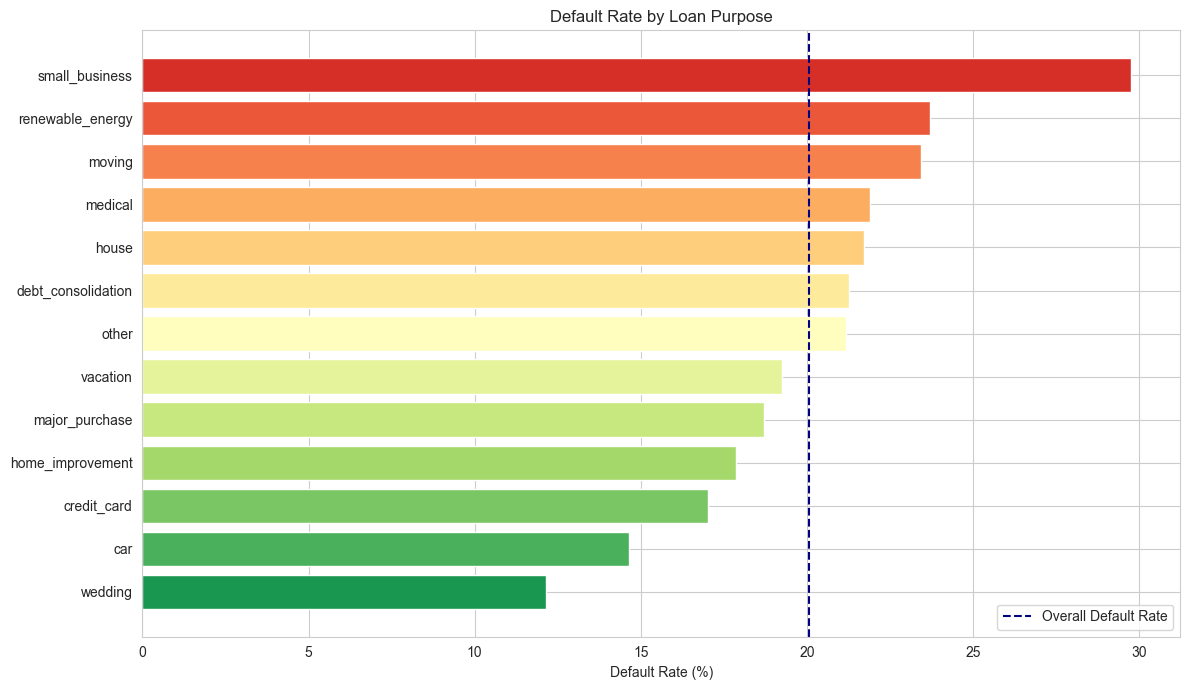

In [8]:
plt.figure(figsize=(12, 7))

colors = plt.cm.RdYlGn_r(
    np.linspace(0.1, 0.9, len(purpose_analysis))
)

bars = plt.barh(
    purpose_analysis['purpose'],
    purpose_analysis['default_rate'] * 100,
    color=colors
)

plt.axvline(
    df['target'].mean() * 100,
    linestyle='--',
    color='navy',
    label='Overall Default Rate'
)

plt.title('Default Rate by Loan Purpose')
plt.xlabel('Default Rate (%)')

plt.legend()

plt.tight_layout()

plt.savefig(
    '../outputs/purpose_default_rates.png',
    dpi=150
)

plt.show()

## Key Insight

Loan purpose materially impacts risk.

Small-business and discretionary loans show elevated default behavior compared to debt-consolidation loans.

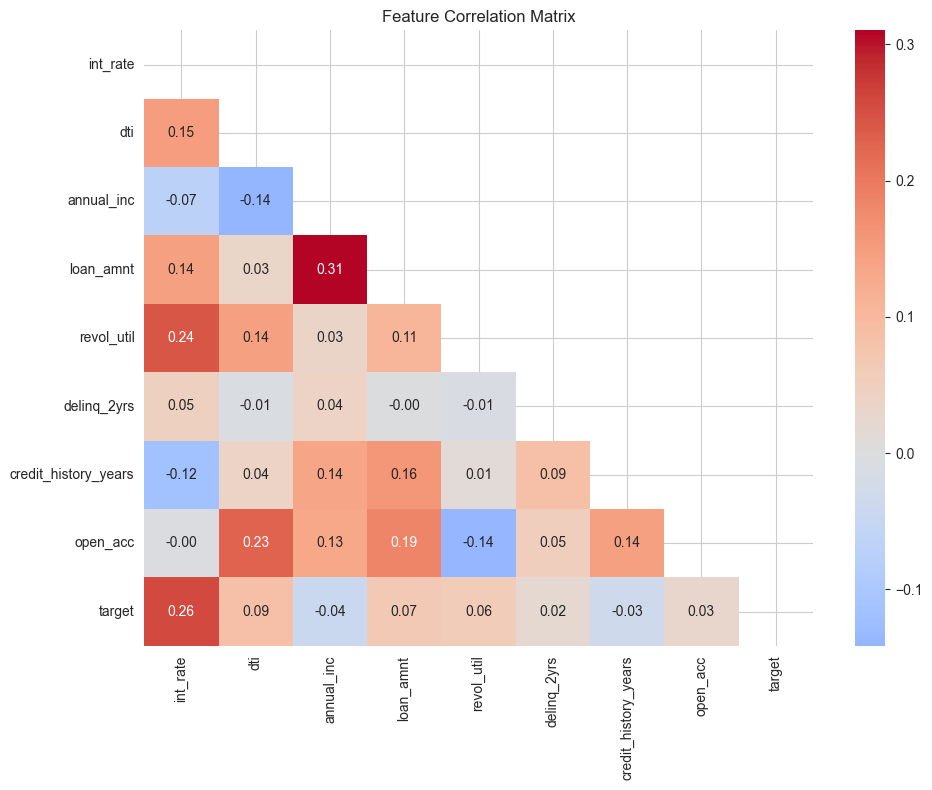

In [9]:
numeric_cols = df.select_dtypes(
    include=[np.number]
).columns.tolist()

corr_matrix = df[numeric_cols].corr()

key_features = [
    'int_rate',
    'dti',
    'annual_inc',
    'loan_amnt',
    'revol_util',
    'delinq_2yrs',
    'credit_history_years',
    'open_acc',
    'target'
]

plt.figure(figsize=(10, 8))

mask = np.triu(
    np.ones_like(df[key_features].corr(), dtype=bool)
)

sns.heatmap(
    df[key_features].corr(),
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Feature Correlation Matrix')

plt.tight_layout()

plt.savefig(
    '../outputs/correlation_matrix.png',
    dpi=150
)

plt.show()

## Key Insight

Interest rate, DTI ratio, and revolving utilization show meaningful relationships with default risk.

Some features also exhibit multicollinearity and may need reduction before modeling.

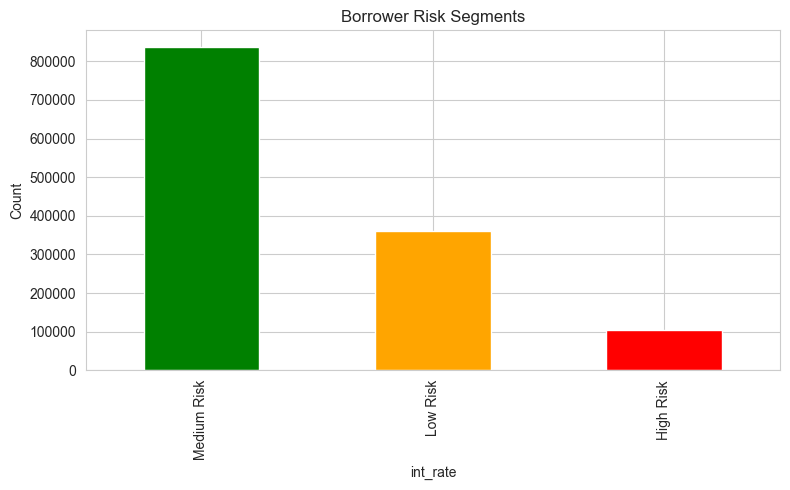

In [10]:
risk_segments = pd.cut(
    df['int_rate'],
    bins=[0, 10, 20, 40],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

segment_counts = risk_segments.value_counts()

plt.figure(figsize=(8, 5))

segment_counts.plot(
    kind='bar',
    color=['green', 'orange', 'red']
)

plt.title('Borrower Risk Segments')
plt.ylabel('Count')

plt.tight_layout()

plt.savefig(
    '../outputs/risk_segments.png',
    dpi=150
)

plt.show()

# Executive Summary

## Major Findings

1. Loan grade is highly predictive of default behavior.
2. High debt-to-income ratios strongly increase risk.
3. Interest rate aligns with borrower risk profile.
4. Revolving utilization is a useful risk signal.
5. Loan purpose materially affects repayment behavior.
6. Small-business loans exhibit elevated defaults.
7. Longer credit histories generally reduce risk.
8. Several features exhibit strong correlation and may require feature selection before modeling.